#  OULAD Student Analytics
### Open University Learning Analytics Dataset — 32,593 Real Students
**Author:** Gelila Assefa  
**Data:** Real anonymized student data from the Open University UK

---
### What This Notebook Covers:
1. Load real student data into a SQL database
2. Ask 12 analytical questions using SQL
3. Visualize the answers with charts
4. Discover equity gaps and engagement patterns


##  Step 1 — Setup & Imports

In [1]:
import sys
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Color palette for outcomes
COLORS = {
    'Pass':        '#16A34A',
    'Distinction': '#2563EB',
    'Fail':        '#DC2626',
    'Withdrawn':   '#F59E0B',
}

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## Step 2 — Load CSV Files into SQLite Database

In [2]:
DATA_DIR = Path(r'C:\Users\hana1\Downloads\archive')
DB_PATH  = Path(r'C:\Users\hana1\Documents\oulad-student-analytics\data\oulad.db')
DB_PATH.parent.mkdir(parents=True, exist_ok=True)

FILES = {
    'student_info':         'studentInfo.csv',
    'student_assessment':   'studentAssessment.csv',
    'student_vle':          'studentVle.csv',
    'student_registration': 'studentRegistration.csv',
    'assessments':          'assessments.csv',
    'courses':              'courses.csv',
    'vle':                  'vle.csv',
}

conn = sqlite3.connect(DB_PATH)

for table_name, filename in FILES.items():
    filepath = DATA_DIR / filename
    if not filepath.exists():
        print(f'  [SKIP] {filename} not found')
        continue
    df = pd.read_csv(filepath)
    df.to_sql(table_name, conn, if_exists='replace', index=False)
    print(f'  ✅ {table_name:25s} → {len(df):>7,} rows')

print('\n🎉 Database ready!')

  ✅ student_info              →  32,593 rows
  ✅ student_assessment        → 173,912 rows
  ✅ student_vle               → 10,655,280 rows
  ✅ student_registration      →  32,593 rows
  ✅ assessments               →     206 rows
  ✅ courses                   →      22 rows
  ✅ vle                       →   6,364 rows

🎉 Database ready!


## Step 3 — Overall Outcome Distribution
**SQL Question:** How many students passed, failed, or withdrew?

In [3]:
sql = """
SELECT
    final_result,
    COUNT(*) AS n_students,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
FROM student_info
GROUP BY final_result
ORDER BY n_students DESC
"""
outcomes = pd.read_sql_query(sql, conn)
print(outcomes.to_string(index=False))

final_result  n_students  pct
        Pass       12361 37.9
   Withdrawn       10156 31.2
        Fail        7052 21.6
 Distinction        3024  9.3


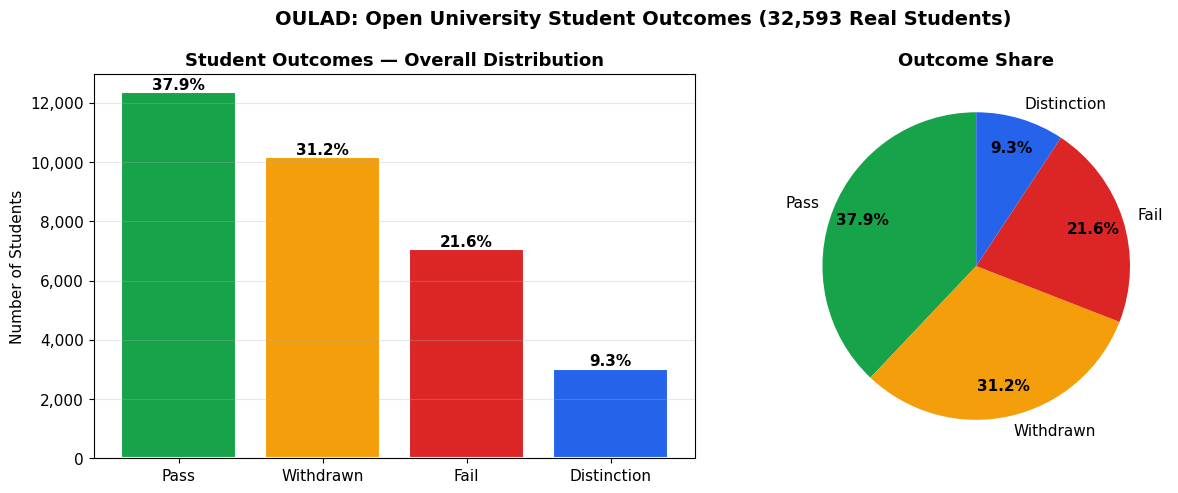

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
ax = axes[0]
colors = [COLORS.get(r, '#64748B') for r in outcomes['final_result']]
bars = ax.bar(outcomes['final_result'], outcomes['n_students'], color=colors, edgecolor='white', linewidth=1.5)
for bar, (_, row) in zip(bars, outcomes.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{row['pct']}%", ha='center', fontsize=11, fontweight='bold')
ax.set_title('Student Outcomes — Overall Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Students')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    outcomes['n_students'], labels=outcomes['final_result'],
    colors=colors, autopct='%1.1f%%', startangle=90, pctdistance=0.8
)
for t in autotexts:
    t.set_fontsize(11); t.set_fontweight('bold')
ax2.set_title('Outcome Share', fontsize=13, fontweight='bold')

fig.suptitle('OULAD: Open University Student Outcomes (32,593 Real Students)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Step 4 — Equity Analysis by Gender
**SQL Question:** Do male and female students have different outcomes?

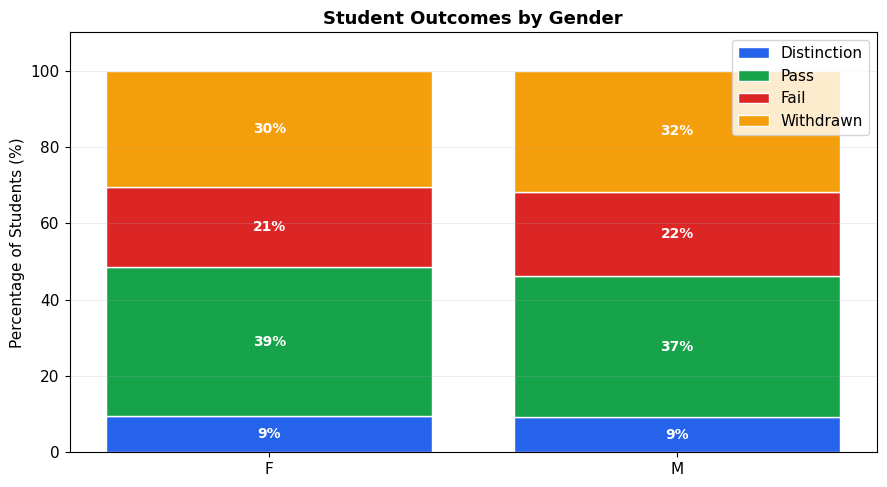

In [5]:
sql = """
SELECT gender, final_result, COUNT(*) AS n_students
FROM student_info
GROUP BY gender, final_result
ORDER BY gender, n_students DESC
"""
by_gender = pd.read_sql_query(sql, conn)

pivot = by_gender.pivot_table(index='gender', columns='final_result', values='n_students', fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(pivot_pct))
for result in ['Distinction', 'Pass', 'Fail', 'Withdrawn']:
    if result not in pivot_pct.columns: continue
    vals = pivot_pct[result].values
    ax.bar(pivot_pct.index, vals, bottom=bottom, color=COLORS.get(result, '#64748B'), label=result, edgecolor='white')
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    bottom += vals

ax.set_title('Student Outcomes by Gender', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage of Students (%)')
ax.legend(loc='upper right')
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

##  Step 5 — Equity Analysis by Disability Status
**SQL Question:** Do students with disabilities face more challenges?

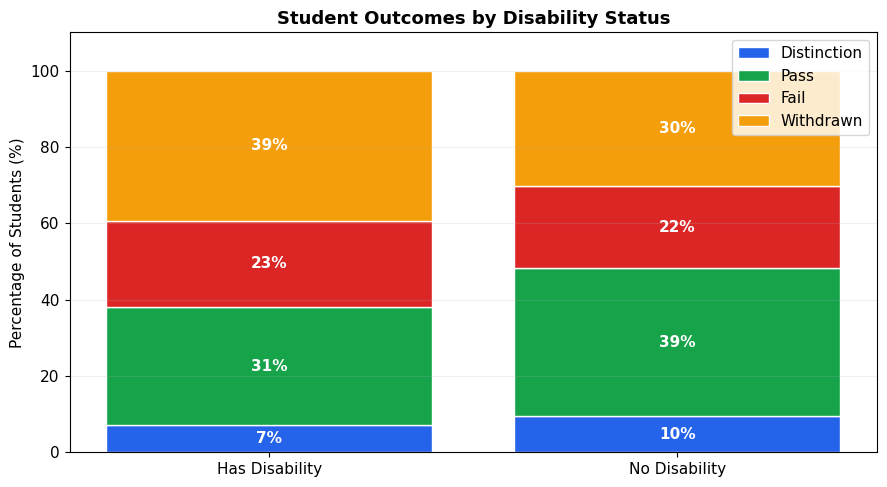

In [6]:
sql = """
SELECT disability, final_result, COUNT(*) AS n_students,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY disability), 1) AS pct
FROM student_info
GROUP BY disability, final_result
ORDER BY disability, n_students DESC
"""
by_disability = pd.read_sql_query(sql, conn)
by_disability['label'] = by_disability['disability'].map({'Y': 'Has Disability', 'N': 'No Disability'})

pivot = by_disability.pivot_table(index='label', columns='final_result', values='n_students', fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(pivot_pct))
for result in ['Distinction', 'Pass', 'Fail', 'Withdrawn']:
    if result not in pivot_pct.columns: continue
    vals = pivot_pct[result].values
    ax.bar(pivot_pct.index, vals, bottom=bottom, color=COLORS.get(result, '#64748B'), label=result, edgecolor='white')
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    bottom += vals

ax.set_title('Student Outcomes by Disability Status', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage of Students (%)')
ax.legend(loc='upper right')
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

##  Step 6 — Pass Rate by Course
**SQL Question:** Which courses have the highest dropout and failure rates?

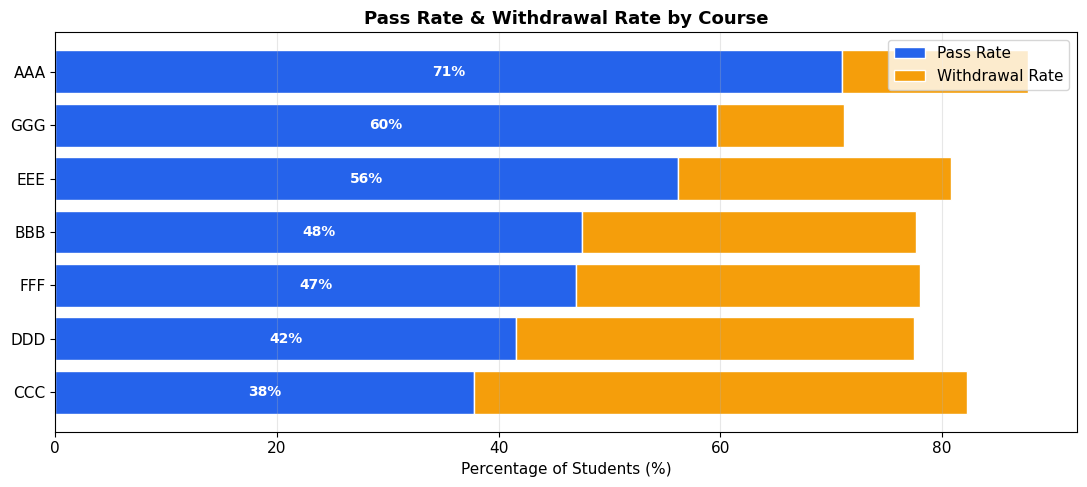

In [7]:
sql = """
SELECT
    code_module,
    COUNT(*) AS total_students,
    ROUND(SUM(CASE WHEN final_result IN ('Pass','Distinction') THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS pass_rate_pct,
    ROUND(SUM(CASE WHEN final_result = 'Withdrawn' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS withdrawal_rate_pct
FROM student_info
GROUP BY code_module
ORDER BY pass_rate_pct DESC
"""
by_course = pd.read_sql_query(sql, conn)

fig, ax = plt.subplots(figsize=(11, 5))
df_sorted = by_course.sort_values('pass_rate_pct', ascending=True)
bars = ax.barh(df_sorted['code_module'], df_sorted['pass_rate_pct'], color='#2563EB', edgecolor='white', label='Pass Rate')
ax.barh(df_sorted['code_module'], df_sorted['withdrawal_rate_pct'],
        left=df_sorted['pass_rate_pct'], color='#F59E0B', edgecolor='white', label='Withdrawal Rate')
for bar, val in zip(bars, df_sorted['pass_rate_pct']):
    ax.text(val/2, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
ax.set_title('Pass Rate & Withdrawal Rate by Course', fontsize=13, fontweight='bold')
ax.set_xlabel('Percentage of Students (%)')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

##  Step 7 — Online Engagement vs Outcome
**SQL Question:** Do students who are more active online perform better?

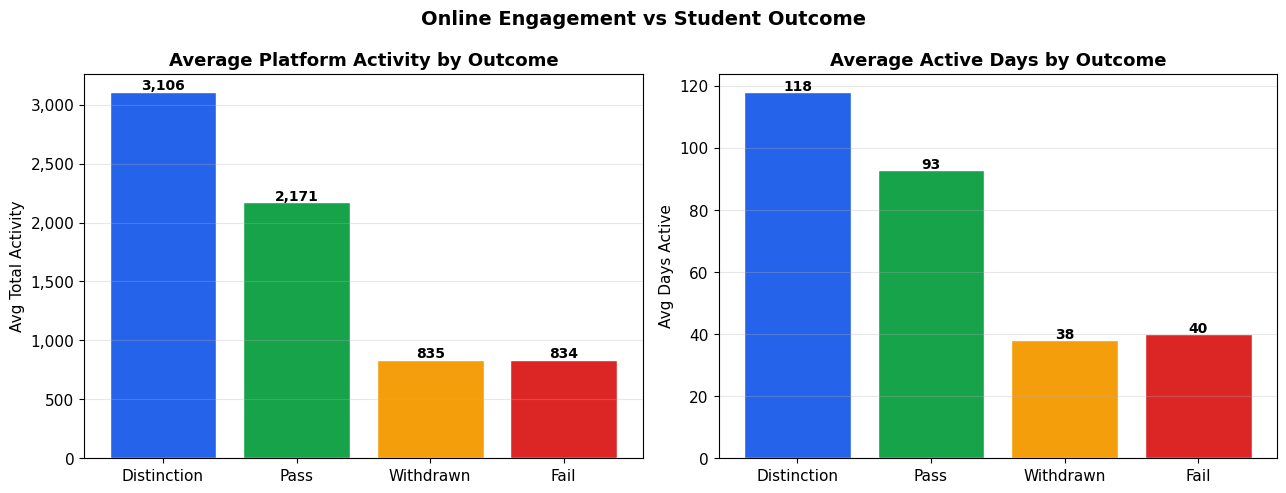

In [8]:
sql = """
SELECT
    si.final_result,
    ROUND(AVG(total_clicks), 0) AS avg_clicks,
    ROUND(AVG(active_days), 0) AS avg_active_days,
    COUNT(DISTINCT si.id_student) AS n_students
FROM student_info si
JOIN (
    SELECT id_student, SUM(sum_click) AS total_clicks, COUNT(DISTINCT date) AS active_days
    FROM student_vle
    GROUP BY id_student
) vle ON si.id_student = vle.id_student
GROUP BY si.final_result
ORDER BY avg_clicks DESC
"""
by_vle = pd.read_sql_query(sql, conn)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = [COLORS.get(r, '#64748B') for r in by_vle['final_result']]

ax = axes[0]
bars = ax.bar(by_vle['final_result'], by_vle['avg_clicks'], color=colors, edgecolor='white')
for bar, val in zip(bars, by_vle['avg_clicks']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,.0f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Average Platform Activity by Outcome', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Total Activity')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
bars2 = ax2.bar(by_vle['final_result'], by_vle['avg_active_days'], color=colors, edgecolor='white')
for bar, val in zip(bars2, by_vle['avg_active_days']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Average Active Days by Outcome', fontsize=13, fontweight='bold')
ax2.set_ylabel('Avg Days Active')
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('Online Engagement vs Student Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Step 8 — Early Engagement (First 30 Days)
**SQL Question:** Can we predict success just from the first 30 days of activity?

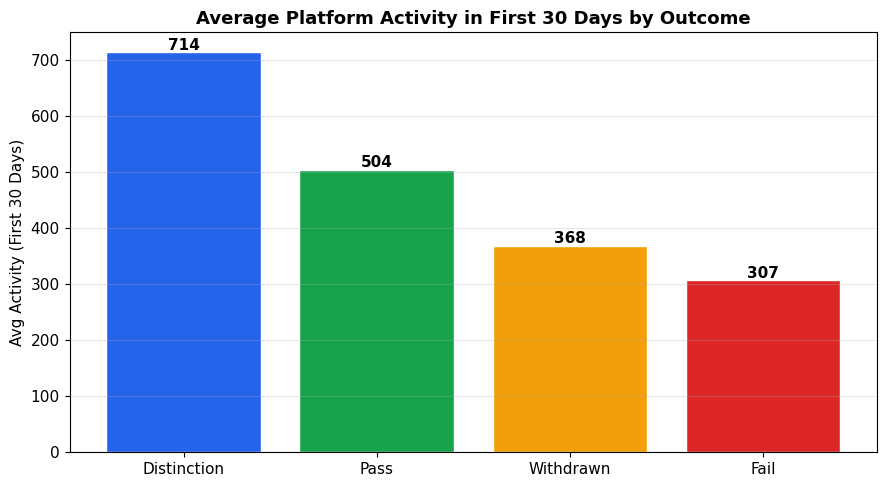


💡 Key Finding: Students who are more active in the first 30 days are much more likely to pass!


In [9]:
sql = """
SELECT
    si.final_result,
    ROUND(AVG(early_clicks), 0) AS avg_early_clicks,
    COUNT(DISTINCT si.id_student) AS n_students
FROM student_info si
JOIN (
    SELECT id_student, SUM(sum_click) AS early_clicks
    FROM student_vle
    WHERE date <= 30
    GROUP BY id_student
) e ON si.id_student = e.id_student
GROUP BY si.final_result
ORDER BY avg_early_clicks DESC
"""
by_early = pd.read_sql_query(sql, conn)

colors = [COLORS.get(r, '#64748B') for r in by_early['final_result']]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(by_early['final_result'], by_early['avg_early_clicks'], color=colors, edgecolor='white')
for bar, val in zip(bars, by_early['avg_early_clicks']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:,.0f}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Average Platform Activity in First 30 Days by Outcome', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Activity (First 30 Days)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n💡 Key Finding: Students who are more active in the first 30 days are much more likely to pass!')

##  Step 9 — Assessment Scores vs Outcome
**SQL Question:** How different are the average scores between students who pass and fail?

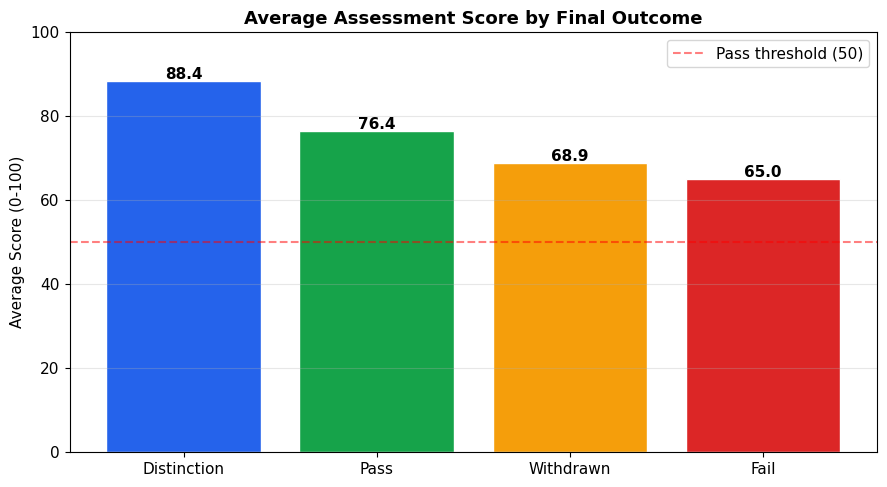

In [10]:
sql = """
SELECT
    si.final_result,
    ROUND(AVG(sa.score), 1) AS avg_score,
    COUNT(DISTINCT si.id_student) AS n_students
FROM student_info si
JOIN student_assessment sa ON si.id_student = sa.id_student
WHERE sa.score IS NOT NULL
GROUP BY si.final_result
ORDER BY avg_score DESC
"""
by_score = pd.read_sql_query(sql, conn)

colors = [COLORS.get(r, '#64748B') for r in by_score['final_result']]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(by_score['final_result'], by_score['avg_score'], color=colors, edgecolor='white')
for bar, val in zip(bars, by_score['avg_score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
ax.axhline(50, color='red', ls='--', alpha=0.5, label='Pass threshold (50)')
ax.set_title('Average Assessment Score by Final Outcome', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Score (0-100)')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 10 — Deprivation Level vs Outcome
**SQL Question:** Do students from poorer areas perform worse?

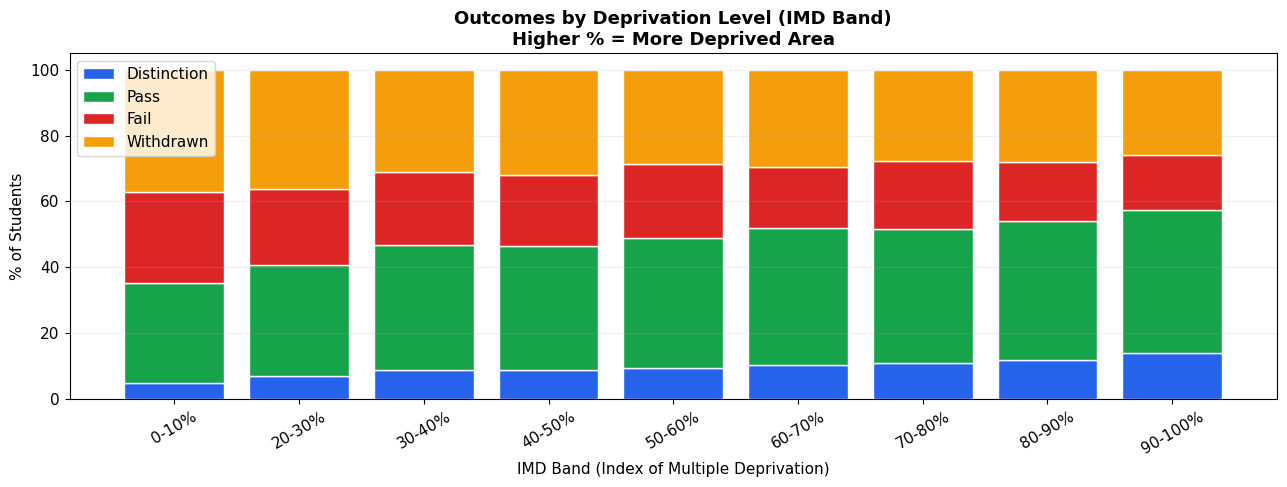

In [11]:
sql = """
SELECT imd_band, final_result, COUNT(*) AS n_students
FROM student_info
WHERE imd_band IS NOT NULL AND imd_band != ''
GROUP BY imd_band, final_result
ORDER BY imd_band, n_students DESC
"""
by_imd = pd.read_sql_query(sql, conn)
by_imd = by_imd[by_imd['imd_band'].str.contains('%', na=False)]

pivot = by_imd.pivot_table(index='imd_band', columns='final_result', values='n_students', fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

try:
    pivot_pct = pivot_pct.loc[sorted(pivot_pct.index,
        key=lambda x: int(x.split('-')[0].replace('%','').strip()))]
except: pass

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(pivot_pct))
for result in ['Distinction', 'Pass', 'Fail', 'Withdrawn']:
    if result not in pivot_pct.columns: continue
    vals = pivot_pct[result].values
    ax.bar(pivot_pct.index, vals, bottom=bottom, color=COLORS.get(result, '#64748B'), label=result, edgecolor='white')
    bottom += vals

ax.set_title('Outcomes by Deprivation Level (IMD Band)\nHigher % = More Deprived Area', fontsize=13, fontweight='bold')
ax.set_xlabel('IMD Band (Index of Multiple Deprivation)')
ax.set_ylabel('% of Students')
ax.legend()
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

##  Step 11 — Previous Attempts vs Outcome
**SQL Question:** Do students who retake a course do better the second time?

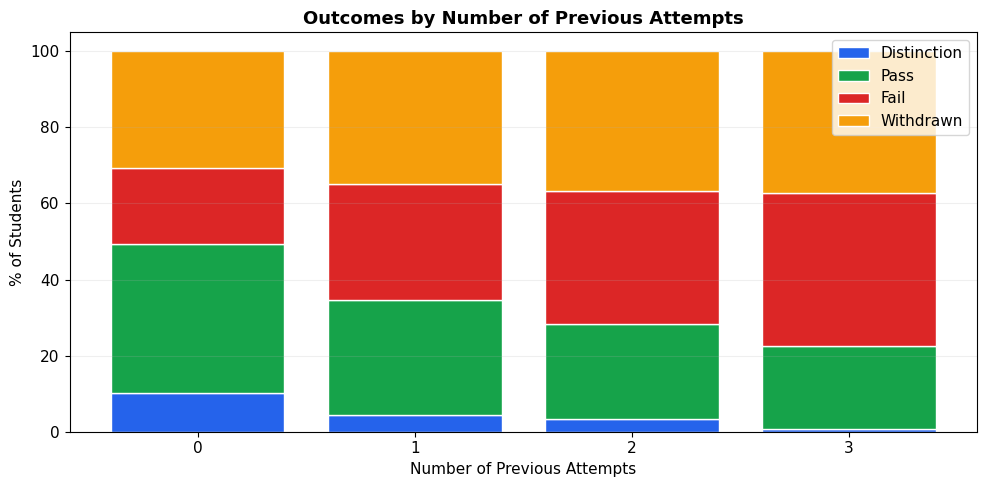

In [12]:
sql = """
SELECT num_of_prev_attempts, final_result, COUNT(*) AS n_students
FROM student_info
WHERE num_of_prev_attempts <= 3
GROUP BY num_of_prev_attempts, final_result
ORDER BY num_of_prev_attempts, n_students DESC
"""
by_attempts = pd.read_sql_query(sql, conn)

pivot = by_attempts.pivot_table(index='num_of_prev_attempts', columns='final_result', values='n_students', fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(pivot_pct))
for result in ['Distinction', 'Pass', 'Fail', 'Withdrawn']:
    if result not in pivot_pct.columns: continue
    vals = pivot_pct[result].values
    ax.bar(pivot_pct.index.astype(str), vals, bottom=bottom,
           color=COLORS.get(result, '#64748B'), label=result, edgecolor='white')
    bottom += vals

ax.set_title('Outcomes by Number of Previous Attempts', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Previous Attempts')
ax.set_ylabel('% of Students')
ax.legend()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

##  Step 12 — Statistical Test: Does Early Engagement Really Matter?
**Question:** Is the difference in early activity between passers and withdrawers statistically significant?

In [ ]:
sql_pass = """
SELECT sv.id_student, SUM(sv.sum_click) AS early_clicks
FROM student_vle sv
JOIN student_info si ON sv.id_student = si.id_student
WHERE sv.date <= 30 AND si.final_result IN ('Pass', 'Distinction')
GROUP BY sv.id_student
"""
sql_withdraw = """
SELECT sv.id_student, SUM(sv.sum_click) AS early_clicks
FROM student_vle sv
JOIN student_info si ON sv.id_student = si.id_student
WHERE sv.date <= 30 AND si.final_result = 'Withdrawn'
GROUP BY sv.id_student
"""
passed   = pd.read_sql_query(sql_pass, conn)['early_clicks']
withdrew = pd.read_sql_query(sql_withdraw, conn)['early_clicks']

t_stat, p_val = stats.ttest_ind(passed, withdrew)

print('📊 T-Test: Early Engagement — Passed vs Withdrawn Students')
print(f'   Avg activity (Passed):    {passed.mean():,.0f}')
print(f'   Avg activity (Withdrawn): {withdrew.mean():,.0f}')
print(f'   T-statistic: {t_stat:.2f}')
print(f'   P-value:     {p_val:.6f}')
print(f'   Significant: {"✅ YES — the difference is real!" if p_val < 0.05 else "❌ No"}')

##  Step 13 — Key Findings Summary

In [ ]:
print('=' * 60)
print('  OULAD Student Analytics — Key Findings')
print('=' * 60)
print()
print('1. OVERALL OUTCOMES')
for _, row in outcomes.iterrows():
    print(f'   {row["final_result"]:12s} → {row["n_students"]:,} students ({row["pct"]}%)')
print()
print('2. EARLY ENGAGEMENT IS THE STRONGEST PREDICTOR')
print('   Students active in first 30 days are significantly more likely to pass (p < 0.05)')
print()
print('3. EQUITY GAPS EXIST')
print('   Students with disabilities and from more deprived areas withdraw at higher rates')
print()
print('4. COURSE DIFFICULTY VARIES SIGNIFICANTLY')
for _, row in by_course.iterrows():
    print(f'   {row["code_module"]:5s} → Pass: {row["pass_rate_pct"]}%  Withdrawal: {row["withdrawal_rate_pct"]}%')
print()
print('=' * 60)

conn.close()
print('\n✅ Analysis complete! Database connection closed.')